In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Paper parameters (Section: Materials and Methods)
N = 1024       # Number of neurons
P = 3          # Number of stored prototypical memories
dt = 0.05      # Simulation time step (Euler-Maruyama)
gain = 5.0     # Slope in activation psi(x) = tanh(gain * x)


In [28]:
# Hopfield model
def generate_memories(N,P):
    """
    Generate P random binary memories of size N.
    Each memory is a vector of -1 and 1.
    """
    memories = np.random.choice([-1, 1], size=(N, P))
    return memories

def compute_saliency(xi, u, N=N):
    # Normalized dot product: (xi^T u / sqrt(N))^2
    dots = (xi.T @ u) / np.sqrt(N)
    return dots ** 2

def build_synaptic_matrix(xi, alpha, N):
    xi_scaled = xi * np.sqrt(alpha)
    return (xi_scaled @ xi_scaled.T) / N

def update_step(x, W, dt, sigma, N):
    psi_x = np.tanh(5.0 * x)
    drift = (-x + W @ psi_x) * dt
    noise = sigma * np.sqrt(dt) * np.random.randn(N)
    return x + drift + noise

def compute_overlap(xi, x, N):
    psi_x = np.tanh(5.0 * x)
    return (xi.T @ psi_x) / N  # Shape (P,)

def run_simulation(xi, dt=0.05, T=30.0, sigma=2.0, N=1024, P=3):
    K = int(T / dt)
    time_points = np.linspace(0, T, K)
    
    # Initial state (random starting point)
    x = np.random.randn(N) * 0.1
    
    # Store history of overlaps: shape (K, P)
    overlap_history = np.zeros((K, P))
    
    for k in range(K):
        t = k * dt
        
        # 1. Define the input u(t) for current phase
        if t < 10.0:
            omega = np.array([3.0, 0.5, 0.5])
        elif t < 20.0:
            omega = np.array([0.5, 3.0, 0.5])
        else:
            omega = np.array([0.5, 0.5, 3.0])

            
        u = xi @ omega /np.sqrt(N) # Mixture input
        
        # 2. Update synaptic matrix W(u)
        alpha = compute_saliency(xi, u)
        W = build_synaptic_matrix(xi, alpha, N)
        
        # 3. Step forward with SDE
        x = update_step(x, W, dt, sigma, N)
        
        # 4. Record the overlaps
        overlap_history[k, :] = compute_overlap(xi, x, N)
        
    return time_points, overlap_history

    

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bkrou\AppData\Local\Temp\ipykernel_17180\1253312140.py:24: SyntaxWarning: invalid escape sequence '\s'
  ['(A) Insulated from Noise ($\sigma = 0$)',
C:\Users\bkrou\AppData\Local\Temp\ipykernel_17180\1253312140.py:25: SyntaxWarning: invalid escape sequence '\s'
  '(B) With Noise ($\sigma = 2$)']):


t =  0.0s | Overlaps: [ 0.0129053   0.05672344 -0.00936419]
t =  5.0s | Overlaps: [1.   0.16 0.14]
t = 10.0s | Overlaps: [1.   0.16 0.14]
t = 15.0s | Overlaps: [0.16 1.   0.06]
t = 20.0s | Overlaps: [0.16 1.   0.06]
t = 25.0s | Overlaps: [0.14 0.06 1.  ]


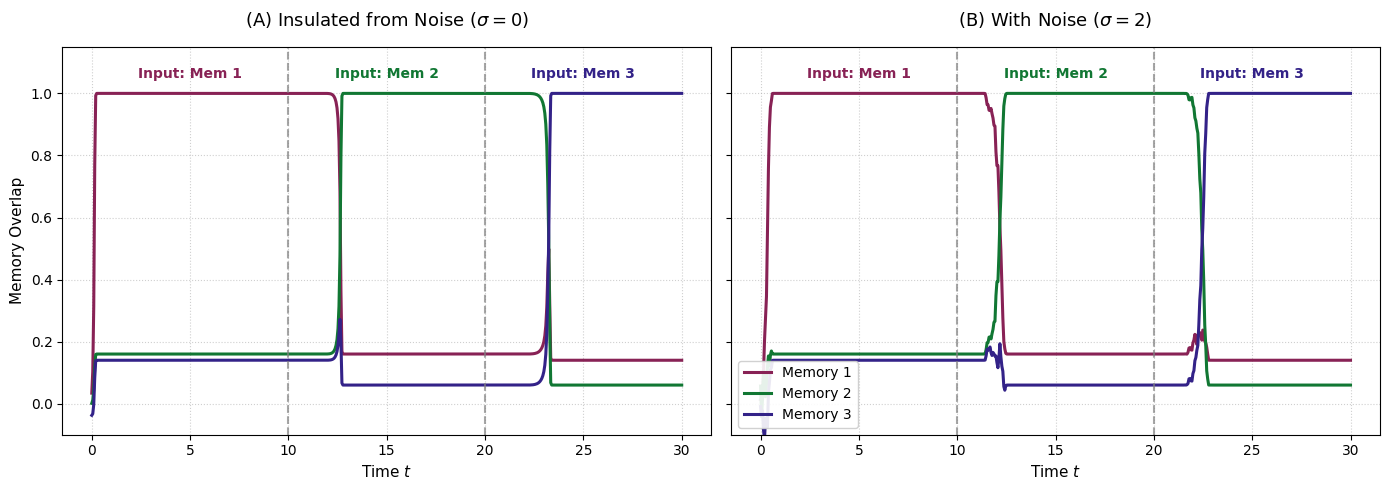

In [30]:
import matplotlib.pyplot as plt

# 1. Generate patterns
np.random.seed(42)
N = 100
P = 3
xi = np.random.choice([-1.0, 1.0], size=(N, P))

# 2. Run both simulations
t_pts, hist_no_noise = run_simulation(xi, dt=0.05, T=30.0, sigma=0.0, N=N, P=P)
t_pts, hist_with_noise = run_simulation(xi, dt=0.05, T=30.0, sigma=1.0, N=N, P=P)

for t_idx in [0, 100, 200, 300, 400, 500]:
    t_val = t_pts[t_idx]
    print(f"t = {t_val:4.1f}s | Overlaps: {hist_with_noise[t_idx]}")


# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = ['#882255', '#117733', '#332288']  # Red, Green, Blue
labels = ['Memory 1', 'Memory 2', 'Memory 3']

for ax, hist, title in zip(axes, [hist_no_noise, hist_with_noise], 
                           ['(A) Insulated from Noise ($\sigma = 0$)', 
                            '(B) With Noise ($\sigma = 2$)']):
    for mu in range(P):
        ax.plot(t_pts, hist[:, mu], label=labels[mu], color=colors[mu], lw=2.2)
        
    # Vertical lines indicating input switches at t = 10 and t = 20
    ax.axvline(10, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(20, color='gray', linestyle='--', alpha=0.7)
    
    # Visual cues for dominant input
    ax.text(5, 1.05, 'Input: Mem 1', ha='center', fontsize=10, weight='bold', color=colors[0])
    ax.text(15, 1.05, 'Input: Mem 2', ha='center', fontsize=10, weight='bold', color=colors[1])
    ax.text(25, 1.05, 'Input: Mem 3', ha='center', fontsize=10, weight='bold', color=colors[2])
    
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Time $t$', fontsize=11)
    ax.set_ylim(-0.1, 1.15)
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Memory Overlap', fontsize=11)
axes[1].legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.show()
